In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pytorch_tabnet.tab_model import TabNetRegressor
import matplotlib.pyplot as plt
import hyperopt
from hyperopt import hp, fmin, tpe, Trials, partial
from hyperopt.early_stop import no_progress_loss
from pytorch_tabnet.pretraining import TabNetPretrainer

In [ ]:

data = pd.read_csv('micedata.csv',header = None)
data = data.values
# 分割输入和目标
X = data[:, 2:]  # 特征
y = data[:, :2]  # 预测目标
# 数据分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 数据标准化
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train )
y_test = scaler.transform(y_test)



In [ ]:
# TabNetPretrainer semi-supervised pretrain
 tabnet_model = TabNetRegressor(
        n_d=params['n_d'],  # 决策层的宽度
        n_a=params['n_a'],  # 注意力机制的宽度
        n_steps=3,  # 决策步骤的数量
        gamma=1.3,  # 用于稀疏特征选择的参数
        n_independent=2,  # 独立GLU层的数量
        n_shared=2,  # 共享GLU层的数量
        epsilon=1e-15,  # 数值稳定性参数
        momentum=0.02,  # 批标准化层的动量
        lambda_sparse=params['lambda_sparse'],  # 稀疏正则化的权重
        seed=42,  # 随机种子
        clip_value=2,  # 梯度裁剪的阈值
        optimizer_fn=torch.optim.Adam,  # 优化器函数
        optimizer_params=dict(lr=params['lr']),  # 优化器的参数
        scheduler_fn=torch.optim.lr_scheduler.StepLR,  # 学习率调度器
        scheduler_params={"step_size":params['Step_size'], "gamma":params['gamma']},  # 调度器的参数
        mask_type="entmax",  # 注意力机制的掩码类型
        input_dim=10346,  # 输入维度（根据数据设置）
        output_dim=2,  # 输出维度（根据数据设置）
        device_name="cuda" if torch.cuda.is_available() else "cpu",  # 训练设备
        verbose=0
    )
    tabnet_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        max_epochs=100,
        patience=30,
        batch_size=32,  # 设置批量大小
        virtual_batch_size=16  # 设置虚拟批量大小
    )
    print(params)
    print(np.min(tabnet_model.history['val_0_mse']))
    return np.min(tabnet_model.history['val_0_mse'])


  # Supervised loss
  y_loss = tf.losses.softmax_MSE(y_input, y_hat)
  # Unsupervised loss
  yu_loss = tf.reduce_mean(tf.nn.moments(yv_hat, axes = 0)[1])

  # Define variables
  p_vars = [v for v in tf.trainable_variables() \
            if v.name.startswith('predictor')]
  # Define solver
  solver = tf.train.AdamOptimizer().minimize(y_loss + \
                                 beta * yu_loss, var_list=p_vars)



unsupervised_model = TabNetPretrainer(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type='entmax' # "sparsemax"
)

tabnet_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        max_epochs=100,
        patience=30,
        batch_size=32,  # 设置批量大小
        virtual_batch_size=16  # 设置虚拟批量大小
    )
    print(params)
    print(np.min(tabnet_model.history['val_0_mse']))
    return np.min(tabnet_model.history['val_0_mse'])

In [ ]:
# 训练模型
def train(params):
    # 初始化 TabNet 回归模型
    tabnet_model = TabNetRegressor(
        n_d=params['n_d'],  # 决策层的宽度
        n_a=params['n_a'],  # 注意力机制的宽度
        n_steps=3,  # 决策步骤的数量
        gamma=1.3,  # 用于稀疏特征选择的参数
        n_independent=2,  # 独立GLU层的数量
        n_shared=2,  # 共享GLU层的数量
        epsilon=1e-15,  # 数值稳定性参数
        momentum=0.02,  # 批标准化层的动量
        lambda_sparse=params['lambda_sparse'],  # 稀疏正则化的权重
        seed=42,  # 随机种子
        clip_value=2,  # 梯度裁剪的阈值
        optimizer_fn=torch.optim.Adam,  # 优化器函数
        optimizer_params=dict(lr=params['lr']),  # 优化器的参数
        scheduler_fn=torch.optim.lr_scheduler.StepLR,  # 学习率调度器
        scheduler_params={"step_size":params['Step_size'], "gamma":params['gamma']},  # 调度器的参数
        mask_type="entmax",  # 注意力机制的掩码类型
        input_dim=10346,  # 输入维度（根据数据设置）
        output_dim=2,  # 输出维度（根据数据设置）
        device_name="cuda" if torch.cuda.is_available() else "cpu",  # 训练设备
        verbose=0
    )
    tabnet_model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        max_epochs=100,
        patience=30,
        batch_size=32,  # 设置批量大小
        virtual_batch_size=16  # 设置虚拟批量大小
    )
    print(params)
    print(np.min(tabnet_model.history['val_0_mse']))
    return np.min(tabnet_model.history['val_0_mse'])

In [ ]:
param_grid_simple = {'lr': hp.uniform("lr",0.00005,0.1)
                     ,'Step_size':hp.randint('Step_size',290)
                     ,'gamma':hp.uniform('gamma',0.1,0.95)
                     ,'n_d':hp.randint('n_d',512)+1
                     ,'n_a':hp.randint('n_a',512)+1
                     ,'lambda_sparse': hp.uniform("lambda_sparse",0.00001,0.1)
                    }

def param_hyperopt(max_evals=100):

    #保存迭代过程
    trials = Trials()

    #设置提前停止
    early_stop_fn = no_progress_loss(100)

    #定义代理模型
    #algo = partial(tpe.suggest, n_startup_jobs=20, n_EI_candidates=50)
    params_best = fmin(train #目标函数
                       , space = param_grid_simple #参数空间
                       , algo = tpe.suggest
                       #, algo = algo
                       , max_evals = max_evals #允许的迭代次数
                       , verbose=True
                       , trials = trials
                       , early_stop_fn = early_stop_fn
                      )

    #打印最优参数，fmin会自动打印最佳分数
    print("\n","\n","best params: ", params_best,
          "\n")
    return params_best, trials

In [ ]:
param_hyperopt(max_evals=100)

                                                       
Early stopping occurred at epoch 40 with best_epoch = 10 and best_val_0_mse = 0.92962
  0%|          | 0/100 [00:52<?, ?trial/s, best loss=?]

/root/miniconda3/lib/python3.8/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



{'Step_size': 215, 'gamma': 0.9359007069603101, 'lambda_sparse': 0.043574379620828815, 'lr': 0.018534525172718967, 'n_a': 250, 'n_d': 496}
0.9296151687651538                                     
                                                                                   
Early stopping occurred at epoch 39 with best_epoch = 9 and best_val_0_mse = 0.93753
  1%|          | 1/100 [01:47<1:33:26, 56.63s/trial, best loss: 0.9296151687651538]

/root/miniconda3/lib/python3.8/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



{'Step_size': 189, 'gamma': 0.565042234076162, 'lambda_sparse': 0.05786140050627765, 'lr': 0.06672967739690178, 'n_a': 323, 'n_d': 210}
0.9375252443089843                                                                 
                                                                                   
Early stopping occurred at epoch 34 with best_epoch = 4 and best_val_0_mse = 0.93664
  2%|▏         | 2/100 [02:37<1:31:27, 55.99s/trial, best loss: 0.9296151687651538]

...

/root/miniconda3/lib/python3.8/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



{'Step_size': 87, 'gamma': 0.6759822888585412, 'lambda_sparse': 0.020804796011534534, 'lr': 0.03920682862125115, 'n_a': 119, 'n_d': 353}
0.8942950041038695                                                                  
                                                                                    
Early stopping occurred at epoch 37 with best_epoch = 7 and best_val_0_mse = 0.93651
 99%|█████████▉| 99/100 [1:57:55<01:10, 70.76s/trial, best loss: 0.8755941962198934]

/root/miniconda3/lib/python3.8/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



{'Step_size': 121, 'gamma': 0.5712665990075835, 'lambda_sparse': 0.0028997907903793585, 'lr': 0.020653983486634945, 'n_a': 368, 'n_d': 289}
0.9365111402325308                                                                  
100%|██████████| 100/100 [1:57:59<00:00, 70.79s/trial, best loss: 0.8755941962198934]

 
 best params:  {'Step_size': 284, 'gamma': 0.3709222619870043, 'lambda_sparse': 0.02985811111941468, 'lr': 0.046365896550789695, 'n_a': 160, 'n_d': 285} 



({'Step_size': 284,
  'gamma': 0.3709222619870043,
  'lambda_sparse': 0.02985811111941468,
  'lr': 0.046365896550789695,
  'n_a': 160,
  'n_d': 285},
 <hyperopt.base.Trials at 0x7f68dc7ab490>)

In [ ]:
# 训练模型
params = {'Step_size': 284, 'gamma': 0.3709222619870043, 'lambda_sparse': 0.02985811111941468, 'lr': 0.046365896550789695, 'n_a': 161, 'n_d': 286}
# 初始化 TabNet 回归模型
tabnet_model = TabNetRegressor(
    n_d=params['n_d'],  # 决策层的宽度
    n_a=params['n_a'],  # 注意力机制的宽度
    n_steps=3,  # 决策步骤的数量
    gamma=1.3,  # 用于稀疏特征选择的参数
    n_independent=2,  # 独立GLU层的数量
    n_shared=2,  # 共享GLU层的数量
    epsilon=1e-15,  # 数值稳定性参数
    momentum=0.02,  # 批标准化层的动量
    lambda_sparse=params['lambda_sparse'],  # 稀疏正则化的权重
    seed=42,  # 随机种子
    clip_value=2,  # 梯度裁剪的阈值
    optimizer_fn=torch.optim.Adam,  # 优化器函数
    optimizer_params=dict(lr=params['lr']),  # 优化器的参数
    scheduler_fn=torch.optim.lr_scheduler.StepLR,  # 学习率调度器
    scheduler_params={"step_size":params['Step_size'], "gamma":params['gamma']},  # 调度器的参数
    mask_type="entmax",  # 注意力机制的掩码类型
    input_dim=10346,  # 输入维度（根据数据设置）
    output_dim=2,  # 输出维度（根据数据设置）
    device_name="cuda" if torch.cuda.is_available() else "cpu",  # 训练设备
)
tabnet_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=39,
    patience=30,
    batch_size=32,  # 设置批量大小
    virtual_batch_size=16  # 设置虚拟批量大小
)


/root/miniconda3/lib/python3.8/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 8.39179 | val_0_mse: 3.18811 |  0:00:01s
epoch 1  | loss: 1.25246 | val_0_mse: 1.23211 |  0:00:02s
epoch 2  | loss: 1.05765 | val_0_mse: 0.98957 |  0:00:03s
epoch 3  | loss: 1.03867 | val_0_mse: 0.95431 |  0:00:05s
epoch 4  | loss: 1.03033 | val_0_mse: 0.94126 |  0:00:06s
epoch 5  | loss: 1.02358 | val_0_mse: 0.94537 |  0:00:07s
epoch 6  | loss: 1.01594 | val_0_mse: 0.94702 |  0:00:08s
epoch 7  | loss: 1.00015 | val_0_mse: 0.9376  |  0:00:10s
epoch 8  | loss: 1.0094  | val_0_mse: 0.93006 |  0:00:11s
epoch 9  | loss: 0.99711 | val_0_mse: 0.92591 |  0:00:12s
epoch 10 | loss: 0.99492 | val_0_mse: 0.95703 |  0:00:13s
epoch 11 | loss: 1.00274 | val_0_mse: 0.94027 |  0:00:14s
epoch 12 | loss: 0.99633 | val_0_mse: 0.9385  |  0:00:16s
epoch 13 | loss: 0.99099 | val_0_mse: 0.93205 |  0:00:17s
epoch 14 | loss: 0.98404 | val_0_mse: 0.94626 |  0:00:18s
epoch 15 | loss: 0.98905 | val_0_mse: 0.9269  |  0:00:19s
epoch 16 | loss: 0.98987 | val_0_mse: 0.95686 |  0:00:21s
epoch 17 | los

/root/miniconda3/lib/python3.8/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [ ]:
torch.save(tabnet_model, 'tabnet_model.pth')

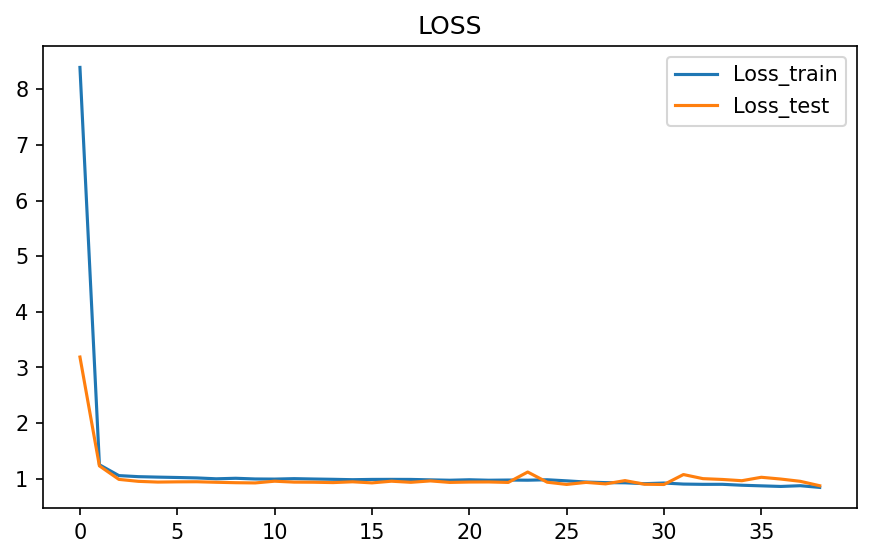

In [ ]:
import matplotlib.pyplot as plt
plt.figure(dpi=150,figsize=(7,4))
plt.plot(tabnet_model.history['loss'][:],label='Loss_train')
plt.plot(tabnet_model.history['val_0_mse'][:],label='Loss_test')
plt.legend()
plt.title('LOSS')
plt.savefig('loss1.png',dpi = 500)
plt.show()

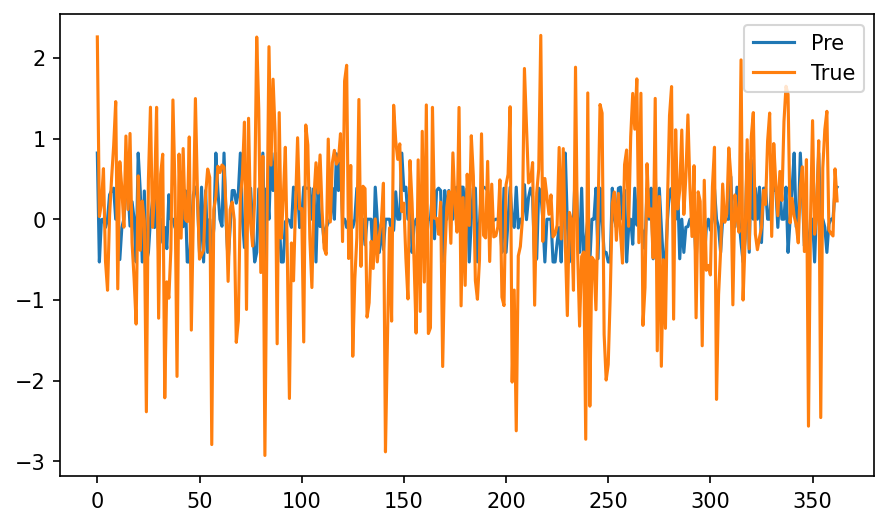

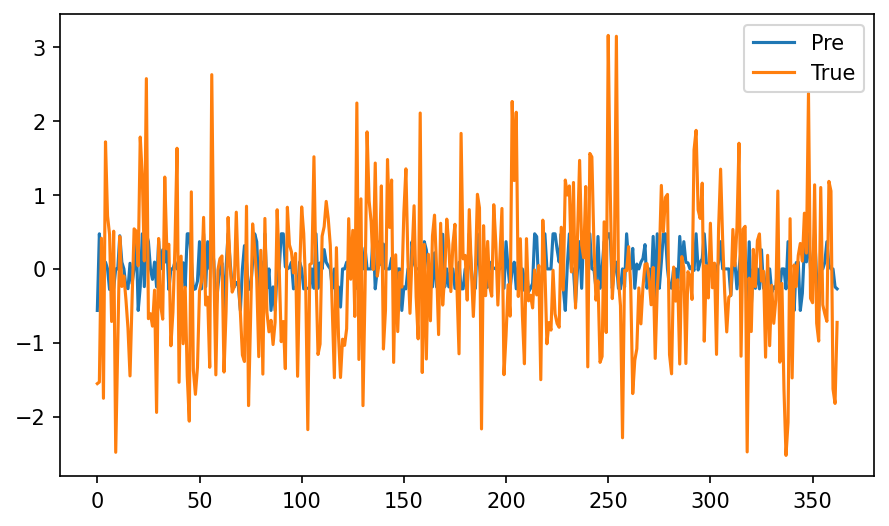

In [ ]:
tabnet_model = torch.load('tabnet_model.pth')
pre = tabnet_model.predict(X_test)
# pre = scaler.inverse_transform(pre)
# Y_test1 = scaler.inverse_transform(y_test)
Y_test1 = y_test
plt.figure(dpi=150,figsize=(7,4))
plt.plot(pre[:,0].reshape(-1),label='Pre')
plt.plot(Y_test1[:,0].reshape(-1),label = 'True')
plt.legend()
plt.show()

plt.figure(dpi=150,figsize=(7,4))
plt.plot(pre[:,1].reshape(-1),label='Pre')
plt.plot(Y_test1[:,1].reshape(-1),label = 'True')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error,explained_variance_score,mean_absolute_error
r2 = r2_score(Y_test1,pre)
ev = explained_variance_score(Y_test1,pre)
mse = mean_squared_error(Y_test1,pre)
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test1,pre)

pre = pre.reshape(-1)
Y_test1 = Y_test1.reshape(-1)
INDEX = []
page = 0
for i in Y_test1:
    if i ==0:
        INDEX.append(page)
    page +=1
if INDEX !=[]:
    Y_test1 = np.delete(Y_test1,INDEX,0)
    pre     = np.delete(pre,INDEX,0)
mape = (sum(abs((pre - Y_test1)/(Y_test1)))/len(Y_test1))
print('r2:',r2)
print('ev:',ev)
print('mse:',mse)
print('rmse:',rmse)
print('mae:',mae)
print('mape:',mape)

r2: 0.06772193016385575
ev: 0.07227512783367956
mse: 0.8755941962198934
rmse: 0.9357319040301519
mae: 0.7276168487691033
mape: 2.3075865430451117


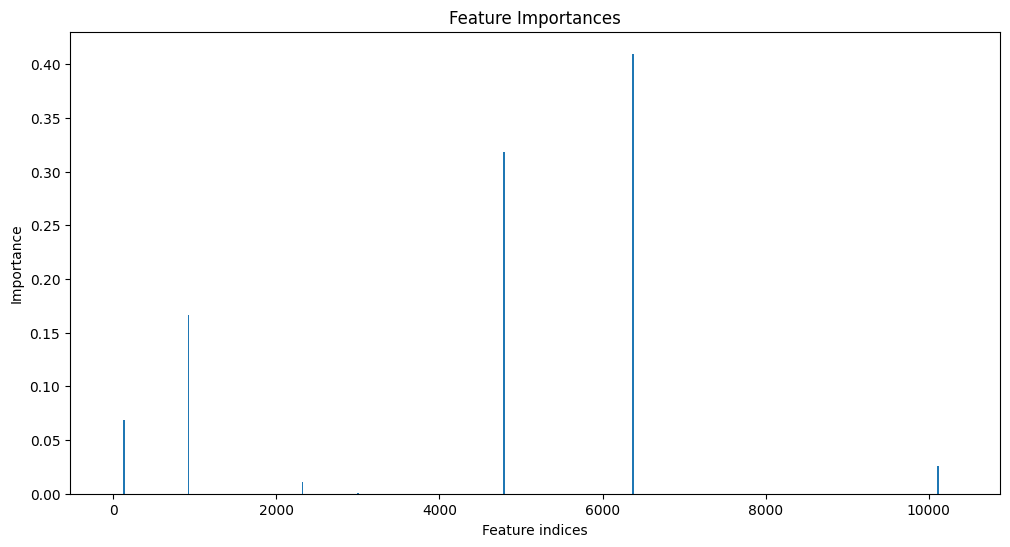

In [ ]:
# 获取特征重要性
feature_importances = tabnet_model.feature_importances_

# 可视化特征重要性
plt.figure(figsize=(12, 6))
plt.bar(range(len(feature_importances)), feature_importances,width=20)
plt.xlabel('Feature indices')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.show()